In [3]:
pip install pandas statistics seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import seaborn as sns
import statistics as sts

In [9]:
df = pd.read_csv( r'C:\Users\guilherme_doge1\Desktop\ciência de dados\Aula 05 - 14-09-2026\Atividade 2\sensores_weg.csv',
                 sep=";")

In [11]:
df.head()

,X0,X1,X2,X3,X4,X4.1,X6,X7,X8,X9,X10,X11
0,1,78.0,JS,Trifasico,48,4,2500000,1,1,0,4430.39,0
1,2,70.3,JS,Monofasico,66,0,2500000,2,0,1,15275.89,0
2,3,79.8,GM,Trifasico,43,0,350000,3,1,1,19460.01,0
3,4,90.3,JS,Trifasico,50,8,350000,2,1,1,NaN,0
4,5,69.2,GM,Monofasico,82,9,800000,1,1,1,19320.11,0


In [17]:
df.shape

(999, 12)

In [52]:
df.columns = [ "Id", "Temperatura", "Unidade", "Tipo_Motor", "Horas_Operacao", "Componentes", "Pressao_Oleo", "Sensores_Ativos", "Conectado_CLP", "Status_Operacional", "Custo_Manutencao", "Falha_Detectada"]

In [19]:
df.groupby(['Unidade']).size()

Unidade
GM    141
JS    515
RP      1
SC    339
SP      1
TD      1
XX      1
dtype: int64

<Axes: xlabel='Unidade'>

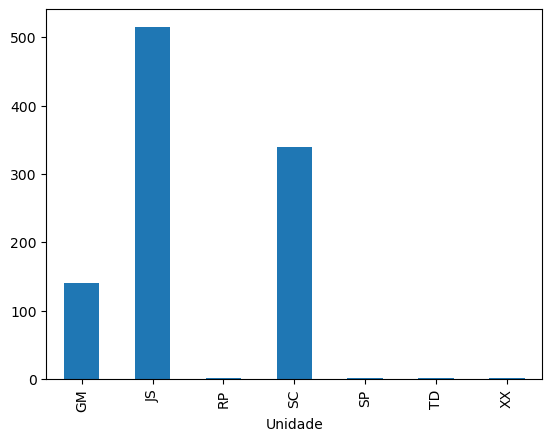

In [32]:
df.groupby(["Unidade"]).size().plot.bar()

In [34]:
df.groupby(["Tipo_Motor"]).size()

Tipo_Motor
M               2
Mono            1
Monofasico    456
T               1
Trif            1
Trifasico     535
dtype: int64

In [42]:
df["Tipo_Motor"].isnull().sum()

3

In [46]:
df["Temperatura"].describe()

count    999.000000
mean      72.435335
std       15.780457
min      -50.000000
25%       64.200000
50%       72.300000
75%       79.800000
max      310.000000
Name: Temperatura, dtype: float64

In [54]:
df["Horas_Operacao"].describe()

count    999.000000
mean      48.345345
std       22.129285
min      -12.000000
25%       30.000000
50%       49.000000
75%       67.000000
max      180.000000
Name: Horas_Operacao, dtype: float64

In [58]:
df.loc[(df["Temperatura"] > 120) | (df["Temperatura"] < 0)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada
5,6,-15.0,GM,Monofasico,22,5,2500000,3,1,0,20150.36,1
22,23,250.0,SC,Trifasico,44,7,800000,1,1,1,17304.28,0
80,81,-50.0,SC,Trifasico,42,1,2500000,3,1,1,20997.21,0
150,151,310.0,SC,Trifasico,31,7,800000,1,0,0,23073.25,0


In [60]:
df.loc[(df["Horas_Operacao"] > 100) | (df["Horas_Operacao"] < 0)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada
18,19,61.1,GM,Monofasico,-5,5,350000,3,1,1,9515.72,0
55,56,83.2,JS,Monofasico,140,3,150000,1,1,1,13903.47,0
120,121,81.5,SC,Monofasico,-12,0,150000,2,1,1,11348.56,0
300,301,62.1,SC,Monofasico,180,1,800000,2,0,1,22165.83,0


In [62]:
df["Custo_Manutencao"].isnull().sum()

13

In [74]:
df[df.duplicated(["Id"], keep=False)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada


In [72]:
df.drop_duplicates(subset="Id", keep="first", inplace=True)

In [78]:
df.loc[~df["Unidade"].isin(["JS", "SC", "GM"]), "Unidade"] = "JS"

In [80]:
df.loc[~df["Unidade"].isin(["JS", "SC", "GM"]), "Unidade"]

Series([], Name: Unidade, dtype: object)

In [84]:
df.loc[df["Tipo_Motor"].isin( ["M", "Mono"] ), "Unidade"] = "Monofasico"
df.loc[df["Tipo_Motor"].isin( ["T", "Trif"] ), "Unidade"] = "Trifasico"

In [86]:
df.loc[df["Tipo_Motor"].isin( ["M", "Mono"] ), "Unidade"]

8      Monofasico
19     Monofasico
112    Monofasico
Name: Unidade, dtype: object

In [88]:
df.loc[df["Tipo_Motor"].isin( ["T", "Trif"] ), "Unidade"]

33    Trifasico
67    Trifasico
Name: Unidade, dtype: object

In [90]:
df.loc[(df["Temperatura"] > 120) | (df["Temperatura"] < 0)] = sts.median(df["Temperatura"])

C:\Users\guilherme_doge1\AppData\Local\Temp\ipykernel_41256\3925477351.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Temperatura"] > 120) | (df["Temperatura"] < 0)] = sts.median(df["Temperatura"])
C:\Users\guilherme_doge1\AppData\Local\Temp\ipykernel_41256\3925477351.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Temperatura"] > 120) | (df["Temperatura"] < 0)] = sts.median(df["Temperatura"])
C:\Users\guilherme_doge1\AppData\Local\Temp\ipykernel_41256\3925477351.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.3' ha

In [92]:
df.loc[(df["Temperatura"] > 120) | (df["Temperatura"] < 0)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada


In [96]:
df.loc[(df["Temperatura"] > 100) | (df["Temperatura"] < 0)] = sts.median(df["Horas_Operacao"])

In [98]:
df.loc[(df["Temperatura"] > 100) | (df["Temperatura"] < 0)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada


In [100]:
df.loc[df["Custo_Manutencao"].isnull()] = sts.median(df["Custo_Manutencao"])

In [102]:
df.loc[df["Custo_Manutencao"].isnull()]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada


In [108]:
df.drop_duplicates(subset="Id", keep="first", inplace=True)

In [114]:
df[df.duplicated(["Id"], keep=False)]

,Id,Temperatura,Unidade,Tipo_Motor,Horas_Operacao,Componentes,Pressao_Oleo,Sensores_Ativos,Conectado_CLP,Status_Operacional,Custo_Manutencao,Falha_Detectada
